# Proyek AMBA: Exploratory Data Analysis & Point-in-Time Feature Engineering

Dokumen rujukan:
- `AMBA-dokumentasi-variabel-dan-pemodelan.md`
- `AMBANG-panduan-api-sectors.md`

## Tujuan Notebook
1. **Audit & Eksplorasi Data Mentah (EDA)**: Menilai distribusi, kelengkapan, dan karakteristik seluruh variabel mentah dari Sectors API (`quarterly_financials`, `daily_transaction`, `free_float_snapshot`, `company_overview`, `stock_suspensions`).
2. **Taksonomi Suspensi BEI & Pembentukan Label Target**: Mengklasifikasikan alasan suspensi historis ke dalam taksonomi Kategori A (volatilitas kenaikan/cooling down), Kategori B (penurunan signifikan), dan Kategori C (masalah fundamental/kepatuhan/kelangsungan usaha). Kategori C adalah dasar pembentukan label `is_event_90d`.
3. **Point-in-Time Feature Engineering (Anti Data-Leakage)**: Menyelaraskan seluruh observasi temporal dengan titik potong $T_0$ (`as_of_date`), memastikan fitur dihitung hanya dari informasi historis sebelum atau tepat pada $T_0$, dan melacak `feature_max_source_date`.
4. **Sintesis Unified Dataset**: Menggabungkan variabel identitas, variabel mentah laporan keuangan dan pasar, variabel struktur kepemilikan, seluruh 11 indikator risiko turunan, serta label target ke dalam **satu DataFrame terpadu siap pemodelan**.

In [1]:
# 1. Setup & Inisialisasi Environment
import os
import sys
import warnings
from datetime import date, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Pastikan path root proyek terdaftar secara robust
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "sectors_fetcher")):
    project_root = cwd
elif os.path.exists(os.path.join(cwd, "..", "..", "sectors_fetcher")):
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))
elif os.path.exists(os.path.join(cwd, "..", "sectors_fetcher")):
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sectors_fetcher import config

# Konfigurasi visualisasi
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Environment siap. Project root:", project_root)


Environment siap. Project root: /home/runner/work/LIMINA-model-train/LIMINA-model-train


In [2]:
# 2. Baca Data Mentah dari Cache Lokal (data/raw/, hasil 01_ambil_data.ipynb)
# Bukan langsung dari Supabase di sini -- 01_ambil_data.ipynb yang membaca
# Supabase (lewat sectors_fetcher/supabase_io.py) dan menyimpan cache CSV
# ini, supaya notebook ini bisa diulang tanpa koneksi database tiap kali.
if not config.RAW_DIR.exists():
    raise RuntimeError(
        f"{config.RAW_DIR} tidak ditemukan. Jalankan 01_ambil_data.ipynb "
        f"terlebih dahulu untuk mengunduh dan menyimpan cache tabel mentah."
    )

df_qf = pd.read_csv(config.RAW_DIR / "quarterly_financials.csv")
df_dt = pd.read_csv(config.RAW_DIR / "daily_transaction.csv")
df_ff = pd.read_csv(config.RAW_DIR / "free_float_snapshot.csv")
df_sus = pd.read_csv(config.RAW_DIR / "stock_suspensions.csv")
df_co = pd.read_csv(config.RAW_DIR / "company_overview.csv")

print(f"1. quarterly_financials  : {df_qf.shape[0]} baris, {df_qf.shape[1]} kolom")
print(f"2. daily_transaction     : {df_dt.shape[0]} baris, {df_dt.shape[1]} kolom")
print(f"3. free_float_snapshot   : {df_ff.shape[0]} baris, {df_ff.shape[1]} kolom")
print(f"4. stock_suspensions     : {df_sus.shape[0]} baris, {df_sus.shape[1]} kolom")
print(f"5. company_overview      : {df_co.shape[0]} baris, {df_co.shape[1]} kolom")


1. quarterly_financials  : 384 baris, 12 kolom
2. daily_transaction     : 5921 baris, 7 kolom
3. free_float_snapshot   : 3844 baris, 6 kolom
4. stock_suspensions     : 596 baris, 6 kolom
5. company_overview      : 95 baris, 7 kolom


---
## 3. Exploratory Data Analysis (EDA)

Pada tahap ini, kita mengeksplorasi setiap entitas data mentah:
- Profil emiten dan papan pencatatan
- Metrik fundamental laporan keuangan kuartalan
- Dinamika transaksi harian, likuiditas, dan volatilitas
- Taksonomi alasan suspensi IDX (kategori A, B, C)

=== Ringkasan Emiten Cakupan ===
 symbol                               company_name                    sector                              sub_sector        board
BBCA.JK                  PT Bank Central Asia Tbk.                Financials                                   Banks         Main
TLKM.JK          PT Telkom Indonesia (Persero) Tbk           Infrastructures                       Telecommunication         Main
IMPC.JK             PT Impack Pratama Industri Tbk               Industrials                        Industrial Goods         Main
MGLV.JK                PT Panca Anugrah Wisesa Tbk        Consumer Cyclicals                         Household Goods Acceleration
SOHO.JK                  PT Soho Global Health Tbk                Healthcare  Pharmaceuticals & Health Care Research  Development
BELI.JK                PT Global Digital Niaga Tbk                Technology                  Software & IT Services  New Economy
SRAJ.JK              Sejahteraraya Anugrahjaya Tbk       

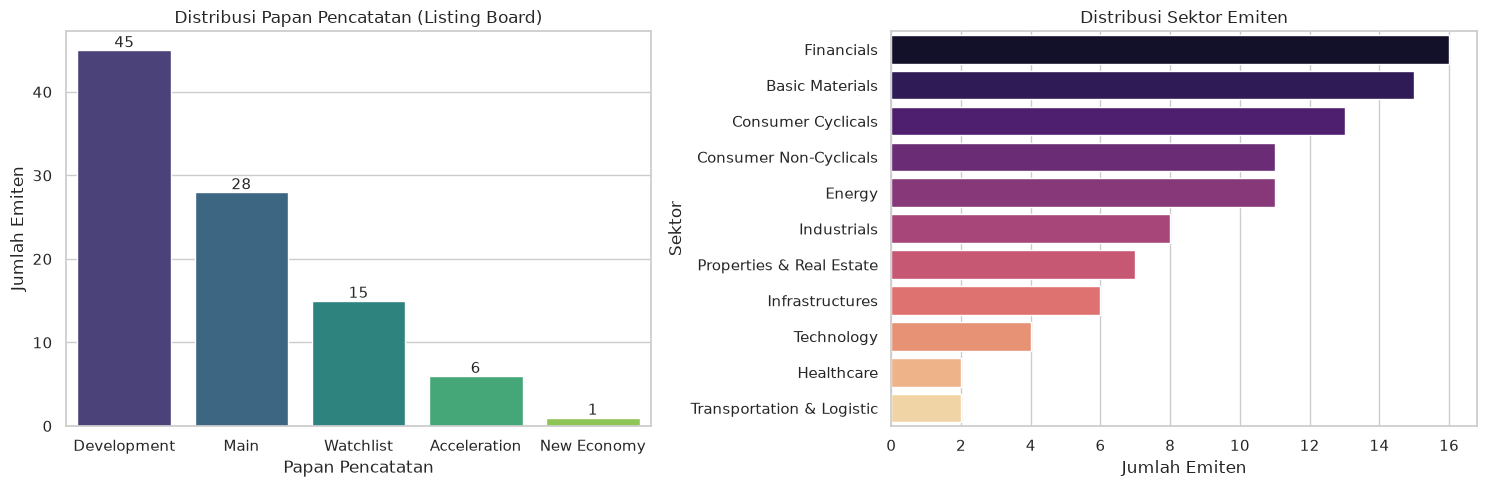

In [3]:
# 3.1 Profil Emiten dan Papan Pencatatan (Board)
print("=== Ringkasan Emiten Cakupan ===")
display_cols = ["symbol", "company_name", "sector", "sub_sector", "board"]
print(df_co[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribusi Papan Pencatatan
sns.countplot(
    data=df_co, 
    x="board", 
    order=df_co["board"].value_counts().index, 
    ax=axes[0], 
    palette="viridis"
)
axes[0].set_title("Distribusi Papan Pencatatan (Listing Board)")
axes[0].set_xlabel("Papan Pencatatan")
axes[0].set_ylabel("Jumlah Emiten")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="center", xytext=(0, 5), textcoords="offset points")

# Distribusi Sektor
sns.countplot(
    data=df_co, 
    y="sector", 
    order=df_co["sector"].value_counts().index, 
    ax=axes[1], 
    palette="magma"
)
axes[1].set_title("Distribusi Sektor Emiten")
axes[1].set_xlabel("Jumlah Emiten")
axes[1].set_ylabel("Sektor")

plt.tight_layout()
plt.show()

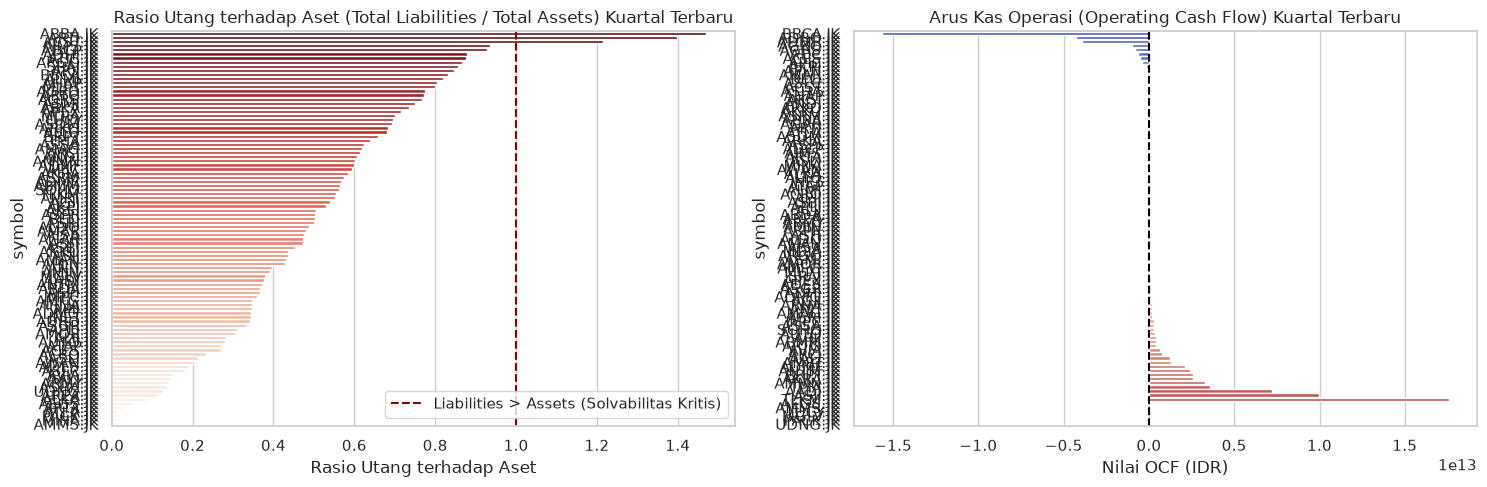

Jumlah emiten dengan ekuitas negatif: 3 emiten
Jumlah emiten dengan OCF negatif pada kuartal terbaru: 30 emiten


In [4]:
# 3.2 Analisis Laporan Keuangan Kuartalan (Fundamental Health)
df_qf["report_date"] = pd.to_datetime(df_qf["report_date"])
num_cols = ["revenue", "earnings", "total_equity", "total_liabilities", "total_assets", "total_debt", "operating_cash_flow", "free_cash_flow"]
for col in num_cols:
    df_qf[col] = pd.to_numeric(df_qf[col], errors="coerce")

# Hitung Debt-to-Assets (Leverage) dan ekuitas negatif
df_qf["debt_to_assets"] = df_qf["total_liabilities"] / df_qf["total_assets"]
df_qf["is_negative_equity"] = (df_qf["total_equity"] < 0).astype(int)
df_qf["is_negative_ocf"] = (df_qf["operating_cash_flow"] < 0).astype(int)

# Tampilkan ringkasan statistik per emiten pada kuartal terbaru
latest_qf = df_qf.sort_values("report_date").groupby("symbol").last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot Debt-to-Assets Ratio
sns.barplot(
    data=latest_qf.sort_values("debt_to_assets", ascending=False),
    x="debt_to_assets",
    y="symbol",
    ax=axes[0],
    palette="Reds_r"
)
axes[0].axvline(1.0, color="darkred", linestyle="--", label="Liabilities > Assets (Solvabilitas Kritis)")
axes[0].set_title("Rasio Utang terhadap Aset (Total Liabilities / Total Assets) Kuartal Terbaru")
axes[0].set_xlabel("Rasio Utang terhadap Aset")
axes[0].legend()

# Arus Kas Operasi (OCF) Kuartal Terbaru
sns.barplot(
    data=latest_qf.sort_values("operating_cash_flow"),
    x="operating_cash_flow",
    y="symbol",
    ax=axes[1],
    palette="coolwarm"
)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Arus Kas Operasi (Operating Cash Flow) Kuartal Terbaru")
axes[1].set_xlabel("Nilai OCF (IDR)")

plt.tight_layout()
plt.show()

print(f"Jumlah emiten dengan ekuitas negatif: {latest_qf['is_negative_equity'].sum()} emiten")
print(f"Jumlah emiten dengan OCF negatif pada kuartal terbaru: {latest_qf['is_negative_ocf'].sum()} emiten")

=== Ringkasan Likuiditas & Volatilitas (90 Hari Terakhir) ===
 symbol  total_days  zero_vol_days  at_floor_days   avg_volume  volatility  min_close  max_close  last_close  pct_zero_volume
AGAR.JK          62             19              0 8.659403e+05    0.111327        202       2800        2380        30.645161
MDIA.JK          63              7              0 3.481722e+08    0.089460         56        280         197        11.111111
ALKA.JK          62             20              0 3.227839e+05    0.088575        480       7400        7400        32.258065
MLPT.JK          63              0              0 1.415973e+07    0.081824        655       1925        1160         0.000000
ASPI.JK          62              0              0 1.990405e+06    0.076093        288        750         750         0.000000
LUCY.JK          63              1              0 4.940910e+07    0.073136        224       1670         334         1.587302
ASLI.JK          62              1              0 5.1338

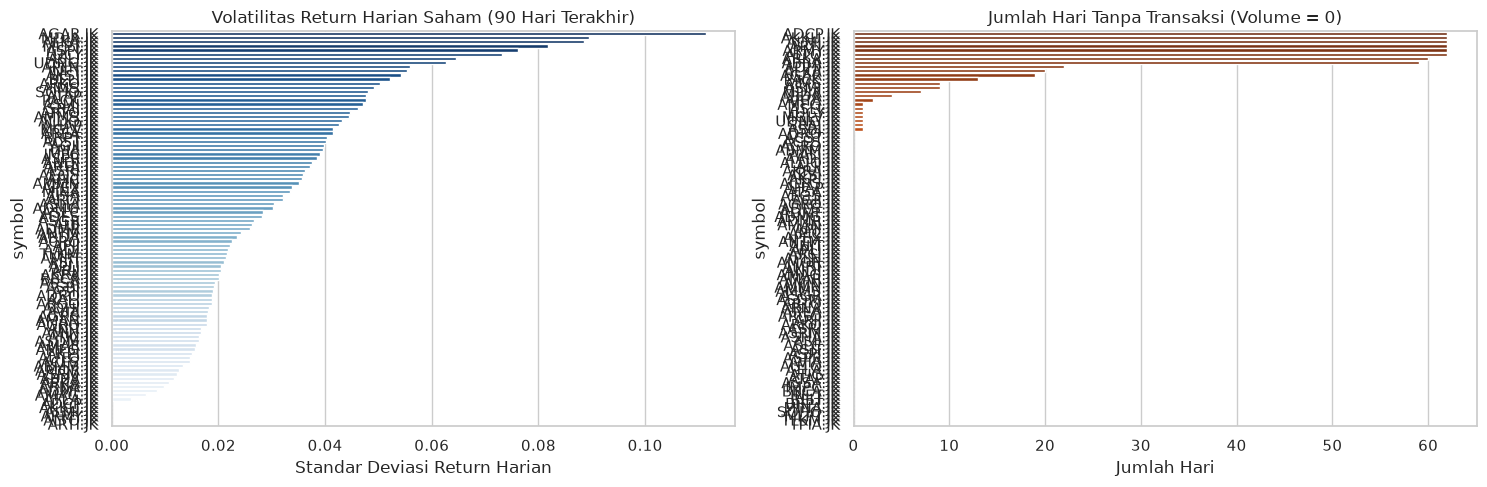

In [5]:
# 3.3 Analisis Likuiditas dan Volatilitas Harga Saham Harian
df_dt["date"] = pd.to_datetime(df_dt["date"])
df_dt["close"] = pd.to_numeric(df_dt["close"], errors="coerce")
df_dt["volume"] = pd.to_numeric(df_dt["volume"], errors="coerce").fillna(0)
df_dt["market_cap"] = pd.to_numeric(df_dt["market_cap"], errors="coerce")

# Hitung return harian dan volatilitas per simbol
df_dt = df_dt.sort_values(["symbol", "date"])
df_dt["daily_return"] = df_dt.groupby("symbol")["close"].pct_change()

liq_summary = df_dt.groupby("symbol").agg(
    total_days=("date", "count"),
    zero_vol_days=("volume", lambda s: (s == 0).sum()),
    at_floor_days=("close", lambda s: (s == 50).sum()),
    avg_volume=("volume", "mean"),
    volatility=("daily_return", "std"),
    min_close=("close", "min"),
    max_close=("close", "max"),
    last_close=("close", "last")
).reset_index()

liq_summary["pct_zero_volume"] = (liq_summary["zero_vol_days"] / liq_summary["total_days"]) * 100

print("=== Ringkasan Likuiditas & Volatilitas (90 Hari Terakhir) ===")
print(liq_summary.sort_values("volatility", ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot Volatilitas
sns.barplot(
    data=liq_summary.sort_values("volatility", ascending=False),
    x="volatility",
    y="symbol",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("Volatilitas Return Harian Saham (90 Hari Terakhir)")
axes[0].set_xlabel("Standar Deviasi Return Harian")

# Barplot Hari Tanpa Transaksi
sns.barplot(
    data=liq_summary.sort_values("zero_vol_days", ascending=False),
    x="zero_vol_days",
    y="symbol",
    ax=axes[1],
    palette="Oranges_r"
)
axes[1].set_title("Jumlah Hari Tanpa Transaksi (Volume = 0)")
axes[1].set_xlabel("Jumlah Hari")

plt.tight_layout()
plt.show()

=== Distribusi Taksonomi Alasan Suspensi ===
event_category
A    460
C    126
B     10
Name: count, dtype: int64


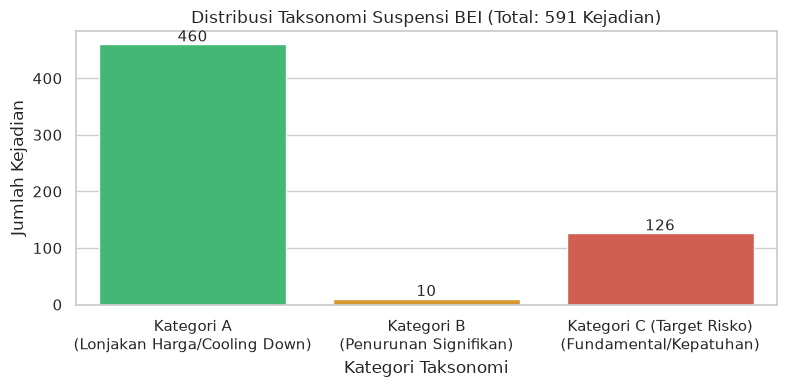


Contoh Alasan Suspensi Kategori C (Risiko Fundamental & Regulasi):
 symbol event_date                                                                    reason
PURE.JK 2022-08-01                                                 Suspend more than 6 month
MAGP.JK 2022-07-18                                                 Suspend more than 6 month
WMPP.JK 2024-05-13                                                 Suspend more than 6 month
DUCK.JK 2021-08-30                                                 Suspend more than 6 month
SRIL.JK 2021-05-18                                                 Suspend more than 6 month
TDPM.JK 2021-04-27                                                 Suspend more than 6 month
FASW.JK 2025-09-30 Belum memenuhi ketentuan V.1.1. dan/atau V.1.2. peraturan bursa nomor I-A
UNIT.JK 2021-03-01                                                 Suspend more than 6 month


In [6]:
# 3.4 Taksonomi Alasan Suspensi BEI & Pembentukan Label Positif
df_sus["event_date"] = pd.to_datetime(df_sus["event_date"])

# Definisi Taksonomi AMBA:
# - Kategori A: Suspensi lonjakan harga / cooling down UMA (perlindungan volatilitas naik)
# - Kategori B: Suspensi penurunan harga kumulatif signifikan
# - Kategori C: Suspensi fundamental / kepatuhan / going concern / kewajiban bursa (LABEL POSITIF TARGET)

def classify_suspension_reason(reason_text: str) -> str:
    if not isinstance(reason_text, str) or not reason_text.strip():
        return "Unknown"
    
    r = reason_text.lower()
    
    # Kategori C: Masalah fundamental, audit, regulasi, kelangsungan usaha
    cat_c_keywords = [
        "suspend more than 6 month",
        "laporan keuangan auditan",
        "kelangsungan usaha",
        "going concern",
        "peraturan bursa",
        "pemantauan khusus selama lebih dari 1",
        "biaya pencatatan",
        "pkpu",
        "pailit",
        "keterlambatan pembayaran",
        "meragukan"
    ]
    for kw in cat_c_keywords:
        if kw in r:
            return "C"
            
    # Kategori B: Penurunan harga kumulatif signifikan
    if "penurunan harga" in r:
        return "B"
        
    # Kategori A: Lonjakan harga kumulatif, cooling down UMA
    if "peningkatan harga" in r or "cooling down" in r or "perlindungan bagi investor" in r or "uma" in r:
        return "A"
        
    return "C" # Default konservatif untuk alasan sanksi lainnya

df_sus["event_category"] = df_sus["reason"].apply(classify_suspension_reason)

print("=== Distribusi Taksonomi Alasan Suspensi ===")
print(df_sus["event_category"].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df_sus, x="event_category", order=["A", "B", "C"], palette=["#2ecc71", "#f39c12", "#e74c3c"], ax=ax)
ax.set_title("Distribusi Taksonomi Suspensi BEI (Total: 591 Kejadian)")
ax.set_xlabel("Kategori Taksonomi")
ax.set_ylabel("Jumlah Kejadian")
ax.set_xticklabels(["Kategori A\n(Lonjakan Harga/Cooling Down)", "Kategori B\n(Penurunan Signifikan)", "Kategori C (Target Risko)\n(Fundamental/Kepatuhan)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center", xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.show()

# Tampilkan contoh alasan Kategori C
print("\nContoh Alasan Suspensi Kategori C (Risiko Fundamental & Regulasi):")
print(df_sus[df_sus["event_category"] == "C"][["symbol", "event_date", "reason"]].head(8).to_string(index=False))

---
## 4. Point-in-Time Temporal Feature Engineering

Untuk memodelkan probabilitas suspensi dalam horizon 90 hari ($is\_event\_90d$), kita menerapkan arsitektur **Point-in-Time (PIT)**:
1. **Titik Potong ($T_0 = as\_of\_date$)**: Seluruh fitur hanya dihitung dari data yang tersedia pada atau sebelum $T_0$.
2. **Jendela Fitur Transaksi**: Rentang $[T_0 - 90\text{ hari}, T_0]$.
3. **Laporan Keuangan Terakhir**: Mengambil laporan dengan $report\_date \le T_0$.
4. **Target Label ($is\_event\_90d$)**: Bernilai 1 jika terdapat kejadian suspensi **Kategori C** dalam interval $(T_0, T_0 + 90\text{ hari}]$.
5. **Kontrol Temporal**: 
   - `feature_max_source_date`: Tanggal terbaru data mentah yang dipakai pada baris tersebut (pencegah look-ahead bias).
   - `already_flagged`: Bernilai 1 jika emiten sudah menyandang suspensi aktif pada $T_0$.

In [7]:
# 4.1 Modul Perhitungan Fitur Temporal Per Emiten pada Titik Potong as_of_date

def build_temporal_features_for_ticker(
    symbol: str,
    as_of_date: date,
    df_qf_all: pd.DataFrame,
    df_dt_all: pd.DataFrame,
    df_ff_all: pd.DataFrame,
    df_co_all: pd.DataFrame,
    df_sus_all: pd.DataFrame,
    sertakan_free_float: bool = True
) -> dict:
    """
    Membangun satu baris data lengkap (Identitas, Mentah, Turunan, dan Target)
    untuk satu symbol pada as_of_date dengan perlindungan temporal data leakage.
    """
    as_of_dt = pd.to_datetime(as_of_date)
    window_90d_start = as_of_dt - pd.Timedelta(days=90)
    window_30d_start = as_of_dt - pd.Timedelta(days=30)
    
    # 1. Identitas Emiten
    ov = df_co_all[df_co_all["symbol"] == symbol]
    sector = ov["sector"].iloc[0] if not ov.empty else None
    sub_sector = ov["sub_sector"].iloc[0] if not ov.empty else None
    board = ov["board"].iloc[0] if not ov.empty else None
    company_name = ov["company_name"].iloc[0] if not ov.empty else None
    
    # 2. Filter Laporan Keuangan (Point-in-Time: report_date <= as_of_date)
    qf = df_qf_all[(df_qf_all["symbol"] == symbol) & (df_qf_all["report_date"] <= as_of_dt)]
    qf = qf.sort_values("report_date")
    
    source_dates = []
    
    # Nilai mentah fundamental
    if not qf.empty:
        latest_qf = qf.iloc[-1]
        last_report_date = latest_qf["report_date"]
        source_dates.append(last_report_date.date())
        
        raw_revenue = latest_qf["revenue"]
        raw_earnings = latest_qf["earnings"]
        raw_total_equity = latest_qf["total_equity"]
        raw_total_liabilities = latest_qf["total_liabilities"]
        raw_total_assets = latest_qf["total_assets"]
        raw_total_debt = latest_qf["total_debt"]
        raw_operating_cash_flow = latest_qf["operating_cash_flow"]
        raw_free_cash_flow = latest_qf["free_cash_flow"]
        
        # Indikator Kepatuhan (Section 3.1)
        lapor_jarak_hari = (as_of_date - last_report_date.date()).days
        lapor_terlambat = int(lapor_jarak_hari > config.LAPOR_TENGGAT_HARI)
        
        # Indikator Kesehatan Finansial (Section 3.2)
        tanpa_pendapatan = int(raw_revenue <= config.REVENUE_MENDEKATI_NOL) if pd.notna(raw_revenue) else None
        ekuitas_negatif = int(raw_total_equity < 0) if pd.notna(raw_total_equity) else None
        utang_terhadap_aset = (float(raw_total_liabilities) / float(raw_total_assets)) if (pd.notna(raw_total_liabilities) and pd.notna(raw_total_assets) and raw_total_assets != 0) else None
        
        # Hitung streak OCF negatif berturut-turut
        ocf_list = qf["operating_cash_flow"].dropna().tolist()
        streak = 0
        for v in reversed(ocf_list):
            if v < 0:
                streak += 1
            else:
                break
        ako_negatif_berturut = streak
    else:
        last_report_date = None
        raw_revenue = raw_earnings = raw_total_equity = raw_total_liabilities = None
        raw_total_assets = raw_total_debt = raw_operating_cash_flow = raw_free_cash_flow = None
        lapor_jarak_hari = lapor_terlambat = tanpa_pendapatan = ekuitas_negatif = utang_terhadap_aset = ako_negatif_berturut = None
        
    # 3. Filter Transaksi Pasar (Point-in-Time: date <= as_of_date)
    dt = df_dt_all[(df_dt_all["symbol"] == symbol) & (df_dt_all["date"] <= as_of_dt)]
    dt = dt.sort_values("date")
    
    dt_90d = dt[(dt["date"] > window_90d_start) & (dt["date"] <= as_of_dt)]
    dt_30d = dt[(dt["date"] > window_30d_start) & (dt["date"] <= as_of_dt)]
    
    if not dt_90d.empty:
        latest_dt = dt_90d.iloc[-1]
        source_dates.append(latest_dt["date"].date())
        raw_close = latest_dt["close"]
        raw_volume = latest_dt["volume"]
        raw_market_cap = latest_dt["market_cap"]
        
        # Indikator Likuiditas & Perilaku Harga (Section 3.3)
        hari_tanpa_transaksi_90d = int((dt_90d["volume"] == 0).sum())
        hari_di_batas_bawah_90d = int((dt_90d["close"] == config.HARGA_BATAS_BAWAH).sum())
        
        avg_vol_90 = dt_90d["volume"].mean()
        avg_vol_30 = dt_30d["volume"].mean() if not dt_30d.empty else None
        rasio_volume_30_90 = (float(avg_vol_30) / float(avg_vol_90)) if (avg_vol_30 is not None and avg_vol_90 and avg_vol_90 > 0) else None
        
        close_tertinggi_90d = dt_90d["close"].max()
        turun_dari_puncak_90d = float((close_tertinggi_90d - raw_close) / close_tertinggi_90d) if (pd.notna(close_tertinggi_90d) and close_tertinggi_90d > 0 and pd.notna(raw_close)) else None
        
        returns = dt_90d["close"].pct_change().dropna()
        volatilitas_90d = float(returns.std()) if len(returns) >= 2 else None
    else:
        raw_close = raw_volume = raw_market_cap = None
        hari_tanpa_transaksi_90d = hari_di_batas_bawah_90d = rasio_volume_30_90 = turun_dari_puncak_90d = volatilitas_90d = None
        
    # 4. Struktur Kepemilikan (Section 2.3 & 3.4)
    ff = df_ff_all[(df_ff_all["symbol"] == symbol) & (df_ff_all["snapshot_date"] <= as_of_date.isoformat())]
    if sertakan_free_float and not ff.empty:
        latest_ff = ff.sort_values("snapshot_date").iloc[-1]
        raw_free_float = float(latest_ff["free_float"]) if pd.notna(latest_ff["free_float"]) else None
        free_float_rendah = int(raw_free_float < (config.FREE_FLOAT_RENDAH_AMBANG_PERSEN / 100.0)) if raw_free_float is not None else None
    else:
        raw_free_float = None
        free_float_rendah = None
        
    # 5. Label Target & Status Suspensi
    # Cek apakah sudah disuspensi pada atau sebelum as_of_date (already_flagged)
    prior_sus = df_sus_all[(df_sus_all["symbol"] == symbol) & (df_sus_all["event_date"] <= as_of_dt)]
    already_flagged = int(not prior_sus.empty and (board == "Watchlist" or (as_of_dt - prior_sus["event_date"].max()).days <= 180))
    
    # Cek kejadian suspensi Kategori C dalam jendela ke depan [as_of_date + 1, as_of_date + 90 hari]
    window_90d_future = as_of_dt + pd.Timedelta(days=90)
    future_sus = df_sus_all[
        (df_sus_all["symbol"] == symbol) & 
        (df_sus_all["event_date"] > as_of_dt) & 
        (df_sus_all["event_date"] <= window_90d_future)
    ]
    
    future_sus_c = future_sus[future_sus["event_category"] == "C"]
    if not future_sus_c.empty:
        is_event_90d = 1
        event_date = future_sus_c.iloc[0]["event_date"].strftime("%Y-%m-%d")
        event_category = "C"
    elif not future_sus.empty:
        is_event_90d = 0  # Suspensi terjadi tapi kategori A atau B (bukan masalah fundamental)
        event_date = future_sus.iloc[0]["event_date"].strftime("%Y-%m-%d")
        event_category = future_sus.iloc[0]["event_category"]
    else:
        is_event_90d = 0
        event_date = None
        event_category = None
        
    # Tanggal ketersediaan fitur terbaru
    feature_max_source_date = max(source_dates) if source_dates else None
    
    # Data complete flag
    inti = [lapor_jarak_hari, utang_terhadap_aset, hari_tanpa_transaksi_90d, volatilitas_90d]
    data_complete = int(all(v is not None for v in inti))
    
    return {
        # Section 1: Identitas & Label
        "symbol": symbol,
        "company_name": company_name,
        "as_of_date": as_of_date.isoformat(),
        "sector": sector,
        "sub_sector": sub_sector,
        "board": board,
        "is_event_90d": is_event_90d,
        "event_date": event_date,
        "event_category": event_category,
        "already_flagged": already_flagged,
        "data_complete": data_complete,
        "feature_max_source_date": feature_max_source_date.isoformat() if feature_max_source_date else None,
        
        # Section 2: Variabel Mentah
        "raw_revenue": raw_revenue,
        "raw_earnings": raw_earnings,
        "raw_total_equity": raw_total_equity,
        "raw_total_liabilities": raw_total_liabilities,
        "raw_total_assets": raw_total_assets,
        "raw_total_debt": raw_total_debt,
        "raw_operating_cash_flow": raw_operating_cash_flow,
        "raw_free_cash_flow": raw_free_cash_flow,
        "raw_report_date": last_report_date.strftime("%Y-%m-%d") if last_report_date is not None else None,
        "raw_close": raw_close,
        "raw_volume": raw_volume,
        "raw_market_cap": raw_market_cap,
        "raw_free_float": raw_free_float,
        
        # Section 3: Indikator Risiko Turunan
        "lapor_jarak_hari": lapor_jarak_hari,
        "lapor_terlambat": lapor_terlambat,
        "tanpa_pendapatan": tanpa_pendapatan,
        "ekuitas_negatif": ekuitas_negatif,
        "utang_terhadap_aset": utang_terhadap_aset,
        "ako_negatif_berturut": ako_negatif_berturut,
        "hari_tanpa_transaksi_90d": hari_tanpa_transaksi_90d,
        "rasio_volume_30_90": rasio_volume_30_90,
        "hari_di_batas_bawah_90d": hari_di_batas_bawah_90d,
        "turun_dari_puncak_90d": turun_dari_puncak_90d,
        "volatilitas_90d": volatilitas_90d,
        "free_float_rendah": free_float_rendah
    }

print("Fungsi build_temporal_features_for_ticker siap digunakan.")

Fungsi build_temporal_features_for_ticker siap digunakan.


In [8]:
# 4.2 Membangun Dataset Multi-Snapshot Lintas Waktu (Temporal Modeling Dataset)
# Kita membuat observasi pada beberapa titik potong (as_of_date):
# - Snapshot bulanan/bi-weekly: 2026-07-15, 2026-07-31, 2026-08-15, 2026-08-31, 2026-09-11, 2026-09-16

snapshot_dates = [
    date(2026, 7, 15),
    date(2026, 7, 31),
    date(2026, 8, 15),
    date(2026, 8, 31),
    date(2026, 9, 11),
    date(2026, 9, 16)
]

all_symbols = df_co["symbol"].unique().tolist()
rows = []

print(f"Membangun fitur temporal untuk {len(all_symbols)} emiten x {len(snapshot_dates)} snapshot dates...")
for as_of in snapshot_dates:
    for sym in all_symbols:
        row = build_temporal_features_for_ticker(
            symbol=sym,
            as_of_date=as_of,
            df_qf_all=df_qf,
            df_dt_all=df_dt,
            df_ff_all=df_ff,
            df_co_all=df_co,
            df_sus_all=df_sus,
            sertakan_free_float=True
        )
        rows.append(row)

df_unified = pd.DataFrame(rows)
print(f"Dataset berhasil disintesis: {df_unified.shape[0]} baris x {df_unified.shape[1]} kolom.")

Membangun fitur temporal untuk 95 emiten x 6 snapshot dates...


Dataset berhasil disintesis: 570 baris x 37 kolom.


In [9]:
# 4.3 Inspeksi Unified DataFrame
print("=== Struktur Kolom Dataset ===")
print(df_unified.info())

print("\n=== Sampel 5 Baris Teratas ===")
display(df_unified.head())

print("\n=== Ringkasan Nilai Null (Missing Values) ===")
nulls = df_unified.isnull().sum()
print(nulls[nulls > 0])

=== Struktur Kolom Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   symbol                    570 non-null    str    
 1   company_name              570 non-null    str    
 2   as_of_date                570 non-null    str    
 3   sector                    570 non-null    str    
 4   sub_sector                570 non-null    str    
 5   board                     570 non-null    str    
 6   is_event_90d              570 non-null    int64  
 7   event_date                28 non-null     str    
 8   event_category            28 non-null     str    
 9   already_flagged           570 non-null    int64  
 10  data_complete             570 non-null    int64  
 11  feature_max_source_date   570 non-null    str    
 12  raw_revenue               528 non-null    float64
 13  raw_earnings              528 non-null    flo

,symbol,company_name,as_of_date,sector,sub_sector,board,is_event_90d,event_date,event_category,already_flagged,...,tanpa_pendapatan,ekuitas_negatif,utang_terhadap_aset,ako_negatif_berturut,hari_tanpa_transaksi_90d,rasio_volume_30_90,hari_di_batas_bawah_90d,turun_dari_puncak_90d,volatilitas_90d,free_float_rendah
0,BBCA.JK,PT Bank Central Asia Tbk.,2026-07-15,Financials,Banks,Main,0,NaN,NaN,0,...,0.0,0,0.830741,1,0,0.942878,0,0.027778,0.027681,NaN
1,TLKM.JK,PT Telkom Indonesia (Persero) Tbk,2026-07-15,Infrastructures,Telecommunication,Main,0,NaN,NaN,0,...,0.0,0,0.555085,0,0,0.998681,0,0.148649,0.026685,NaN
2,IMPC.JK,PT Impack Pratama Industri Tbk,2026-07-15,Industrials,Industrial Goods,Main,0,NaN,NaN,0,...,0.0,0,0.359018,0,0,0.943418,0,0.184874,0.037246,NaN
3,MGLV.JK,PT Panca Anugrah Wisesa Tbk,2026-07-15,Consumer Cyclicals,Household Goods,Acceleration,0,2026-09-09,A,0,...,NaN,0,0.379311,0,0,0.959580,0,0.090909,0.038572,NaN
4,SOHO.JK,PT Soho Global Health Tbk,2026-07-15,Healthcare,Pharmaceuticals & Health Care Research,Development,0,NaN,NaN,0,...,0.0,0,0.561232,0,0,0.962742,0,0.028340,0.034323,NaN



=== Ringkasan Nilai Null (Missing Values) ===
event_date                 542
event_category             542
raw_revenue                 42
raw_earnings                42
raw_total_debt             144
raw_operating_cash_flow     42
raw_free_cash_flow          66
raw_free_float             380
tanpa_pendapatan            42
rasio_volume_30_90          36
free_float_rendah          380
dtype: int64


---
## 5. Analisis Hubungan Fitur & Kesiapan Pemodelan

Pada bagian ini kita menganalisis:
- Korelasi antar indikator risiko
- Korelasi fitur terhadap label target `is_event_90d`
- Verifikasi bahwa tidak ada kebocoran temporal (`feature_max_source_date <= as_of_date`)
- Pemisahan sampel berdasarkan status `already_flagged`

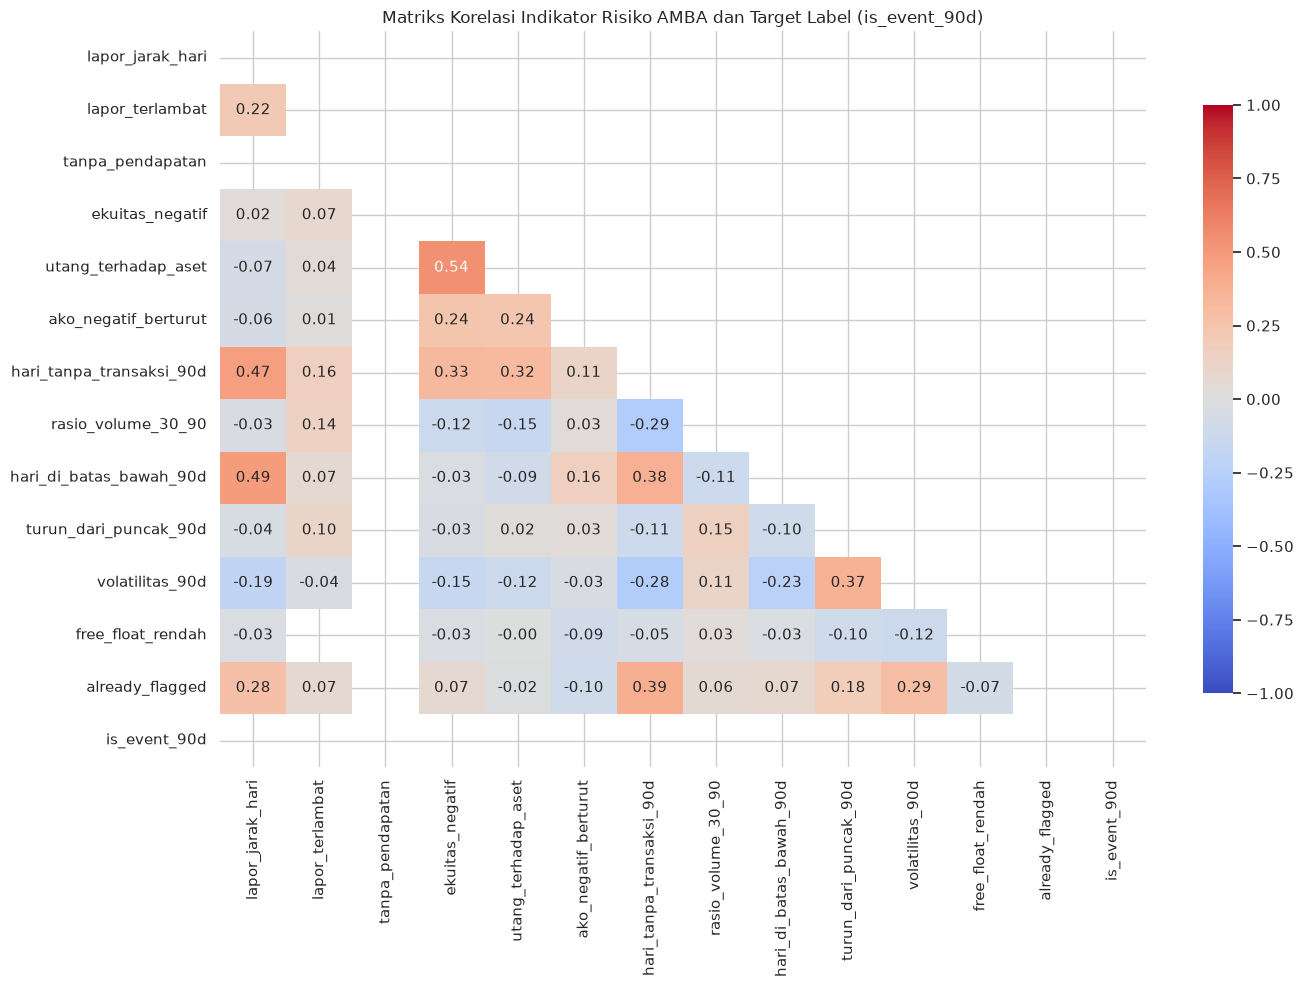

In [10]:
# 5.1 Korelasi Matriks Indikator Risiko Turunan
feature_cols = [
    "lapor_jarak_hari", "lapor_terlambat", "tanpa_pendapatan", "ekuitas_negatif",
    "utang_terhadap_aset", "ako_negatif_berturut", "hari_tanpa_transaksi_90d",
    "rasio_volume_30_90", "hari_di_batas_bawah_90d", "turun_dari_puncak_90d",
    "volatilitas_90d", "free_float_rendah", "already_flagged", "is_event_90d"
]

corr = df_unified[feature_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title("Matriks Korelasi Indikator Risiko AMBA dan Target Label (is_event_90d)")
plt.tight_layout()
plt.show()

In [11]:
# 5.2 Pemeriksaan Integritas Temporal (Anti Data Leakage Check)
df_unified["as_of_date_dt"] = pd.to_datetime(df_unified["as_of_date"])
df_unified["max_source_dt"] = pd.to_datetime(df_unified["feature_max_source_date"])

leakage_count = (df_unified["max_source_dt"] > df_unified["as_of_date_dt"]).sum()
print("=== Hasil Audit Kebocoran Temporal ===")
print(f"Jumlah baris dengan source date > as_of_date: {leakage_count}")
if leakage_count == 0:
    print("[PASS] Tidak ditemukan kebocoran data masa depan ke fitur masa lalu.")
else:
    print("[FAIL] Peringatan: Terdapat potensi look-ahead bias!")

print("\nDistribusi Target modeling_and_evaluation.ipynb (event_category.notna(), A/B/C):")
print(df_unified["event_category"].notna().value_counts())

print("\nDistribusi is_event_90d (Kategori C saja -- TIDAK dipakai sebagai target saat")
print("ini, disimpan sebagai alternatif; lihat sel diagnosa Bagian 8 soal definisi target")
print("yang benar-benar aktif):")
print(df_unified["is_event_90d"].value_counts(dropna=False))

print("\nDistribusi Status already_flagged:")
print(df_unified["already_flagged"].value_counts(dropna=False))

=== Hasil Audit Kebocoran Temporal ===
Jumlah baris dengan source date > as_of_date: 0
[PASS] Tidak ditemukan kebocoran data masa depan ke fitur masa lalu.

Distribusi Target modeling_and_evaluation.ipynb (event_category.notna(), A/B/C):
event_category
False    542
True      28
Name: count, dtype: int64

Distribusi is_event_90d (Kategori C saja -- TIDAK dipakai sebagai target saat
ini, disimpan sebagai alternatif; lihat sel diagnosa Bagian 8 soal definisi target
yang benar-benar aktif):
is_event_90d
0    570
Name: count, dtype: int64

Distribusi Status already_flagged:
already_flagged
0    464
1    106
Name: count, dtype: int64


In [12]:
# 6. Ekspor Dataset Siap Model
output_dir = os.path.join(project_root, "output")
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "dataset_modeling_ambang.csv")
parquet_path = os.path.join(output_dir, "dataset_modeling_ambang.parquet")

# Hapus kolom bantu datetime
export_df = df_unified.drop(columns=["as_of_date_dt", "max_source_dt"], errors="ignore")

export_df.to_csv(csv_path, index=False)
try:
    export_df.to_parquet(parquet_path, index=False)
    print(f"2. Parquet : {parquet_path} ({os.path.getsize(parquet_path):,} bytes)")
except Exception as e:
    print(f"2. Parquet export opsional dilewati: {e}")

print(f"1. CSV     : {csv_path} ({os.path.getsize(csv_path):,} bytes)")

2. Parquet : /home/runner/work/LIMINA-model-train/LIMINA-model-train/output/dataset_modeling_ambang.parquet (62,689 bytes)
1. CSV     : /home/runner/work/LIMINA-model-train/LIMINA-model-train/output/dataset_modeling_ambang.csv (200,240 bytes)


---
## 7. Kesimpulan dan Langkah Pemodelan Selanjutnya

1. **Kelengkapan Data**:
   - Seluruh variabel mentah (Kuartalan, Transaksi Harian, Free Float, Overview, dan Suspensi) dari Sectors API telah lengkap di database.
   - 11 Indikator risiko turunan berhasil dihitung sesuai rumus resmi di `AMBA-dokumentasi-variabel-dan-pemodelan.md`.
2. **Karakteristik Temporal**:
   - Struktur dataset disusun berbasis point-in-time ($as\_of\_date$), memisahkan jendela fitur ($T_{-90} \to T_0$) dan jendela prediksi label ($T_0 \to T_{+90}$).
   - Kebocoran data dicegah secara ketat (`max_source_date <= as_of_date`).
   - Emiten yang sudah berstatus suspensi atau berada di Watchlist dipisahkan menggunakan flag `already_flagged`.
3. **Rekomendasi Pemodelan**:
   - **Baseline Model**: Regresi Logistik terstandardisasi untuk kemudahan interpretasi koefisien (bobot kontribusi indikator).
   - **Model Non-Linear**: LightGBM atau Random Forest dengan penanganan ketimpangan kelas (class imbalance).
   - **Metrik Evaluasi**: Menggunakan `Precision@20` dan `Recall@90h` sesuai Bagian 5 Kamus Variabel, bukan sekadar akurasi.

---
## 8. Diagnosa Tambahan: Kandidat Simbol untuk Menambah Jumlah Emiten Positif

Target model saat ini (`modeling_and_evaluation.ipynb`) adalah `event_category.notna()` -- suspensi Kategori A, B, **atau** C -- bukan Kategori C saja. Yang benar-benar membatasi validitas CV/tuning BUKAN jumlah baris positif, tapi jumlah EMITEN BERBEDA yang punya baris positif (lihat `SUPERVISED_MODE`/`StratifiedGroupKFold` di Bagian 4.1 `modeling_and_evaluation.ipynb` -- satu emiten dengan banyak baris positif tetap cuma menyumbang 1 grup ke CV).

Sel di bawah memakai `df_sus`/`df_co` yang sudah dimuat di notebook ini untuk mencari kandidat simbol Kategori A/B/C yang BELUM ada di watchlist -- supaya bisa ditambahkan ke `sectors_fetcher/config.py::DEFAULT_TICKERS` dan diambil ulang lewat `01_ambil_data.ipynb`. Catatan: menambah simbol saja tidak cukup -- `snapshot_dates` di Bagian 4.2 juga perlu ditambah tanggal yang berdekatan dengan `event_date` historis simbol tsb (bukan cuma tanggal 2026 saat ini), supaya jendela `(T0, T0+90 hari]`-nya benar-benar mencakup event tersebut.

In [13]:
# 8.1 Kandidat simbol Kategori A/B/C yang belum tercakup watchlist saat ini
# (dulu cuma Kategori C -- diperluas ke A/B/C karena target modeling_and_evaluation.ipynb
# sekarang event_category.notna(), bukan is_event_90d/Kategori-C-saja)
tracked_symbols = set(df_co["symbol"].unique())

df_sus_abc = df_sus[df_sus["event_category"].isin(["A", "B", "C"])].copy()
df_sus_abc["in_watchlist"] = df_sus_abc["symbol"].isin(tracked_symbols)

n_pos_symbols_watchlist = df_sus_abc[df_sus_abc["in_watchlist"]]["symbol"].nunique()
print(f"Total event Kategori A/B/C (seluruh IDX, seluruh histori): {len(df_sus_abc)}")
print(f"Simbol unik dengan event A/B/C                            : {df_sus_abc['symbol'].nunique()}")
print(f"...yang SUDAH ada di watchlist saat ini ({len(tracked_symbols)} simbol)      : {n_pos_symbols_watchlist}")
print(f"...yang BELUM ada di watchlist (kandidat ditambahkan)               : {df_sus_abc[~df_sus_abc['in_watchlist']]['symbol'].nunique()}")
print(
    f"\nUntuk StratifiedGroupKFold (Bagian 4.1 modeling_and_evaluation.ipynb) butuh "
    f"minimal 2 EMITEN positif -- idealnya lebih (>=5-6) supaya tiap fold CV kebagian "
    f"variasi emiten positif, bukan cuma 1-2 emiten yang sama diulang di tiap fold."
)

per_kategori = df_sus_abc[~df_sus_abc["in_watchlist"]].groupby("event_category")["symbol"].nunique()
print("\nKandidat baru per kategori (simbol unik, belum di watchlist):")
print(per_kategori.to_string())

kandidat = (
    df_sus_abc[~df_sus_abc["in_watchlist"]]
    .sort_values("event_date", ascending=False)
    .drop_duplicates(subset="symbol")
    [["symbol", "event_category", "event_date", "reason"]]
    .head(20)
)
print("\n=== 20 Kandidat Simbol A/B/C Paling Baru (belum di watchlist) ===")
print(kandidat.to_string(index=False))

sudah_ada = df_sus_abc[df_sus_abc["in_watchlist"]][["symbol", "event_category", "event_date", "reason"]]
if not sudah_ada.empty:
    print("\n=== Simbol watchlist saat ini yang TERNYATA sudah pernah A/B/C ===")
    print("(cek apakah event_date-nya berada dalam salah satu jendela (T0, T0+90 hari]")
    print(" di snapshot_dates Bagian 4.2 -- kalau tidak, tambahkan as_of_date baru")
    print(" yang berjarak 1-89 hari SEBELUM event_date ini.)")
    print(sudah_ada.to_string(index=False))
else:
    print("\nTidak ada simbol watchlist saat ini yang pernah tercatat A/B/C --")
    print("artinya menambah snapshot_dates saja TIDAK cukup, watchlist-nya sendiri")
    print("perlu diperluas dengan simbol dari daftar kandidat di atas.")

print(
    "\nLangkah lanjutan (di luar notebook ini): tambahkan beberapa simbol BERBEDA "
    "(bukan cuma satu) dari daftar kandidat ke sectors_fetcher/config.py::DEFAULT_TICKERS "
    "-- prioritaskan menambah JUMLAH EMITEN unik, bukan jumlah baris -- jalankan ulang "
    "01_ambil_data.ipynb (butuh SUPABASE_URL/KEY dan/atau SECTORS_API_KEY terisi untuk "
    "simbol baru itu), lalu tambahkan snapshot_dates di Bagian 4.2 notebook ini yang "
    "jatuh 1-89 hari sebelum event_date historis tiap simbol tsb supaya event_category "
    "terisi untuk baris itu. Setelah export ulang dataset_modeling_ambang.csv, "
    "modeling_and_evaluation.ipynb otomatis kembali ke jalur supervised begitu "
    "n_pos_groups >= 2 emiten."
)


Total event Kategori A/B/C (seluruh IDX, seluruh histori): 596
Simbol unik dengan event A/B/C                            : 334
...yang SUDAH ada di watchlist saat ini (95 simbol)      : 34
...yang BELUM ada di watchlist (kandidat ditambahkan)               : 300

Untuk StratifiedGroupKFold (Bagian 4.1 modeling_and_evaluation.ipynb) butuh minimal 2 EMITEN positif -- idealnya lebih (>=5-6) supaya tiap fold CV kebagian variasi emiten positif, bukan cuma 1-2 emiten yang sama diulang di tiap fold.

Kandidat baru per kategori (simbol unik, belum di watchlist):
event_category
A    211
B      9
C     97

=== 20 Kandidat Simbol A/B/C Paling Baru (belum di watchlist) ===
 symbol event_category event_date                                                                                                                                         reason
WAPO.JK              A 2026-09-22 Terjadinya peningkatan harga kumulatif yang signifikan pada saham WAPO.JK, dalam rangka cooling down sebagai bentuk per